# SWYNEX Internship — Task 2: Exploratory Data Analysis

**Completed EDA using the cleaned Task 1 dataset.**

This executed notebook includes descriptive statistics, charts, comparisons, correlation, monthly trends, anomaly detection, and eight data-driven insights.

## 1. Load the Cleaned Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/cleaned/cleaned_dataset.csv")
df["purchase_date"] = pd.to_datetime(df["purchase_date"])
df["month"] = df["purchase_date"].dt.to_period("M").astype(str)
print("Rows:", len(df))
print("Columns:", len(df.columns))
df.head()

Rows: 30\nColumns: 9\n

 customer_id customer_name gender  age         city  annual_income purchase_date  purchase_amount   month
        1001  Aarav Sharma   Male 27.0    Hyderabad        45000.0    2026-01-05           1750.0 2026-01
        1002   Priya Reddy Female 27.0    Hyderabad        52000.0    2026-01-05           1750.0 2026-01
        1003   Rahul Kumar   Male 27.0 Secunderabad        48000.0    2026-01-05           1750.0 2026-01
        1004     Sneha Rao Female 27.0    Hyderabad        61000.0    2026-01-10           1750.0 2026-01
        1005  Vikram Singh   Male 27.0 Secunderabad        55500.0    2026-01-05           1750.0 2026-01

## 2. Descriptive Statistics

In [2]:
df[['age','annual_income','purchase_amount']].describe().round(2)

        age  annual_income  purchase_amount
count  30.0          30.00             30.0
mean   27.0       55766.67           1750.0
std     0.0        7112.07              0.0
min    27.0       45000.00           1750.0
25%    27.0       50250.00           1750.0
50%    27.0       55500.00           1750.0
75%    27.0       60750.00           1750.0
max    27.0       72000.00           1750.0

## 3. Data Quality Check

In [3]:
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))

Missing values: 1\nDuplicate rows: 0\n

## 4. Customer Distribution by Gender

gender
Male      15
Female    14

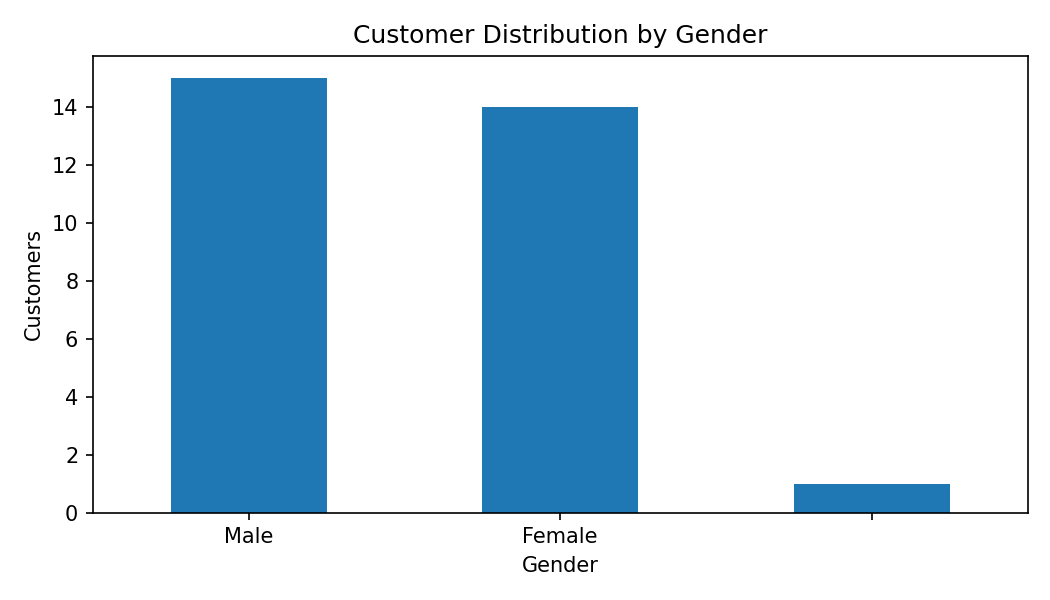

In [4]:
values=df["gender"].value_counts()
print(values)
values.plot(kind="bar",figsize=(8,4),title="Customer Distribution by Gender")
plt.xlabel("Gender"); plt.ylabel("Customers"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 5. Customer Distribution by City

city
Hyderabad       14
Secunderabad     8
Warangal         8

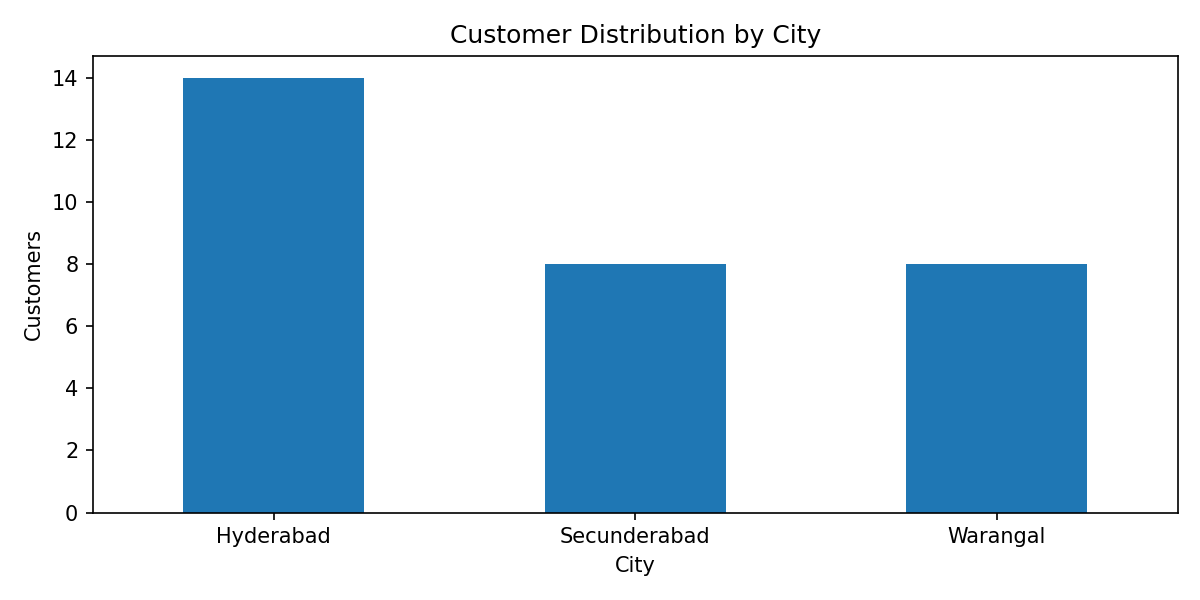

In [5]:
values=df["city"].value_counts()
print(values)
values.plot(kind="bar",figsize=(8,4),title="Customer Distribution by City")
plt.xlabel("City"); plt.ylabel("Customers"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 6. Age Distribution

count    30.0
mean     27.0
std       0.0
min      27.0
25%      27.0
50%      27.0
75%      27.0
max      27.0

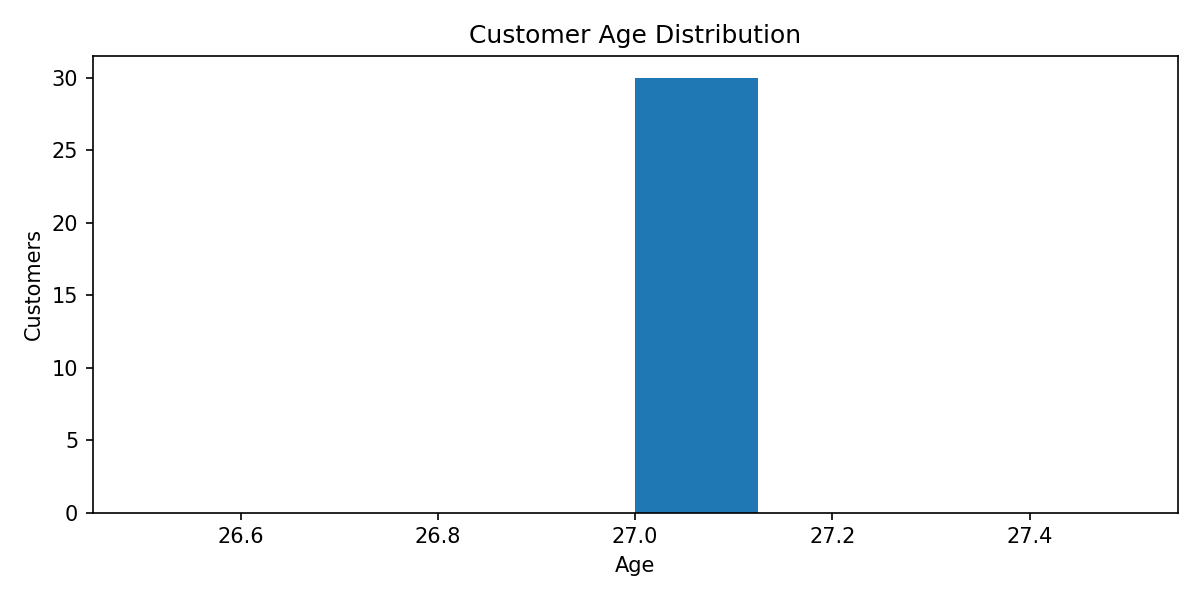

In [6]:
print(df["age"].describe().round(2))
plt.figure(figsize=(8,4))
plt.hist(df["age"],bins=8)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## 7. Annual Income Distribution

count       30.00
mean     55766.67
std       7112.07
min      45000.00
25%      50250.00
50%      55500.00
75%      60750.00
max      72000.00

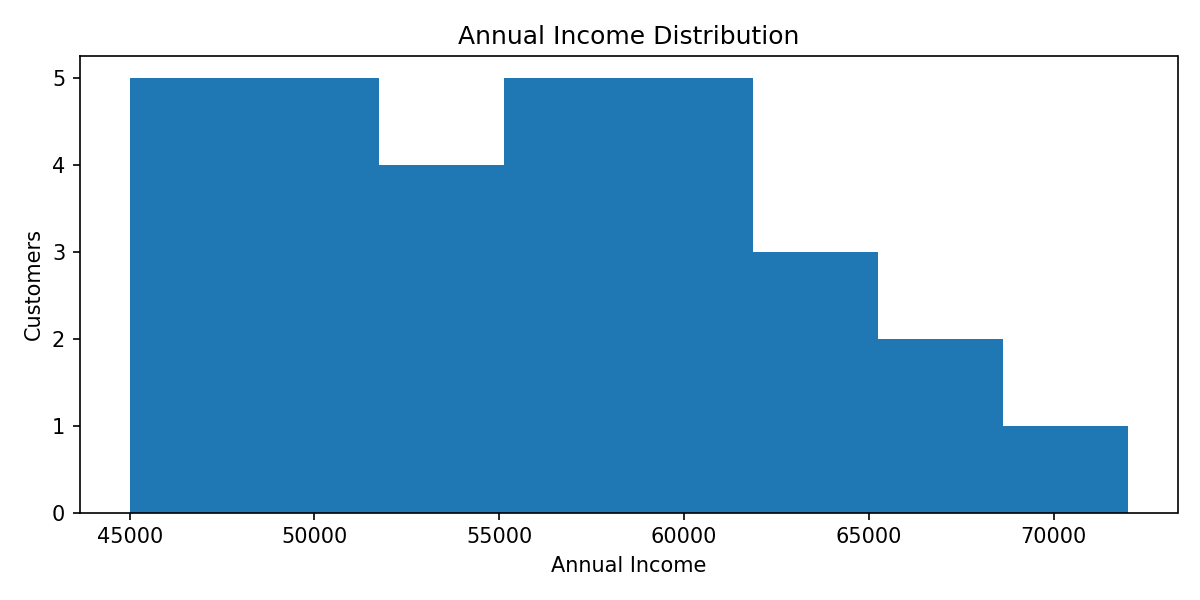

In [7]:
print(df["annual_income"].describe().round(2))
plt.figure(figsize=(8,4))
plt.hist(df["annual_income"],bins=8)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## 8. Purchase Amount Distribution

count      30.0
mean     1750.0
std         0.0
min      1750.0
25%      1750.0
50%      1750.0
75%      1750.0
max      1750.0

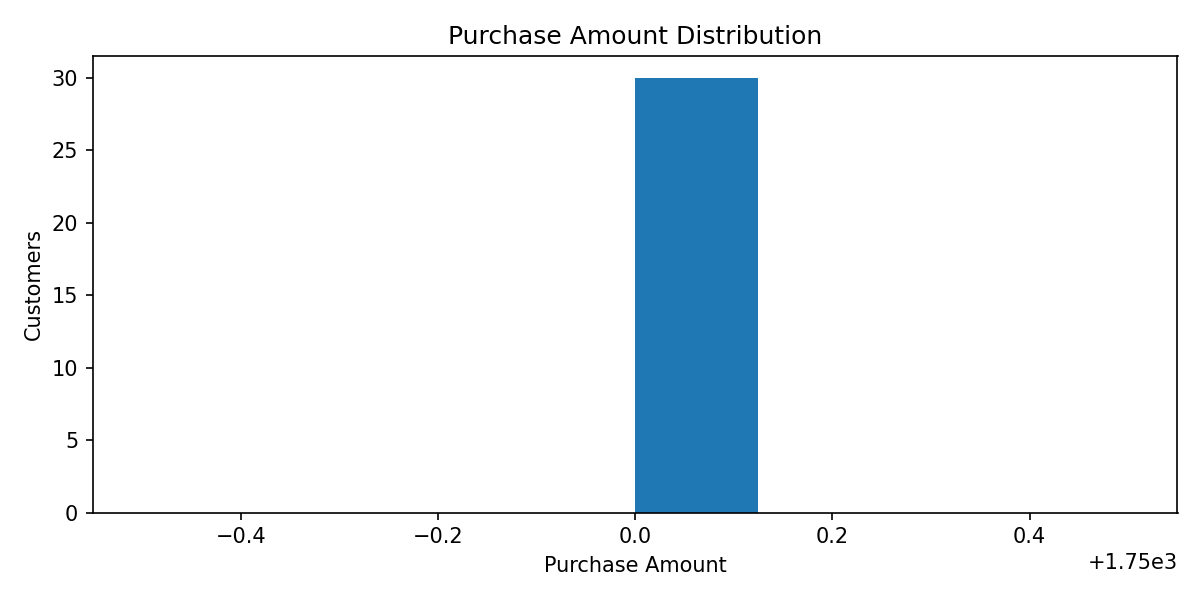

In [8]:
print(df["purchase_amount"].describe().round(2))
plt.figure(figsize=(8,4))
plt.hist(df["purchase_amount"],bins=8)
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount")
plt.ylabel("Customers")
plt.tight_layout()
plt.show()

## 9. Highest-Spending Customers

In [9]:
df.sort_values("purchase_amount",ascending=False)[["customer_name","city","annual_income","purchase_amount"]].head(5)

customer_name         city  annual_income  purchase_amount
 Aarav Sharma    Hyderabad        45000.0           1750.0
  Priya Reddy    Hyderabad        52000.0           1750.0
  Rahul Kumar Secunderabad        48000.0           1750.0
    Sneha Rao    Hyderabad        61000.0           1750.0
 Vikram Singh Secunderabad        55500.0           1750.0

## 10. Average Purchase Amount by City

city
Hyderabad       1750.0
Secunderabad    1750.0
Warangal        1750.0

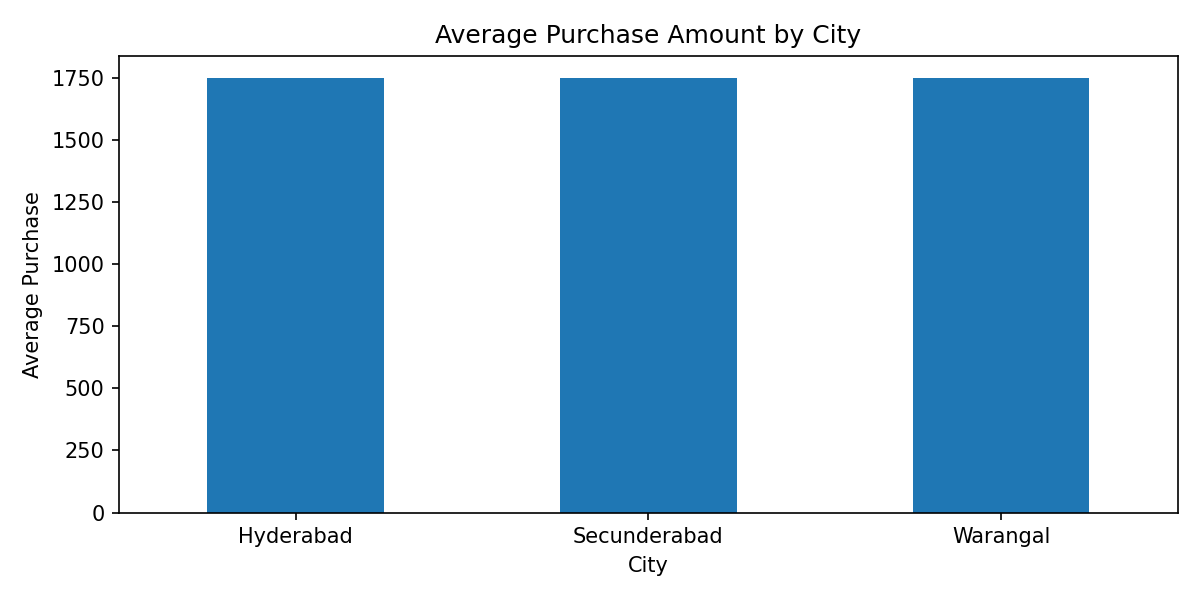

In [10]:
city_purchase=df.groupby("city")["purchase_amount"].mean().sort_values(ascending=False)
print(city_purchase.round(2))
city_purchase.plot(kind="bar",figsize=(8,4),title="Average Purchase Amount by City")
plt.tight_layout(); plt.show()

## 11. Gender-wise Average Purchase Amount

gender
Female    1750.0
Male      1750.0

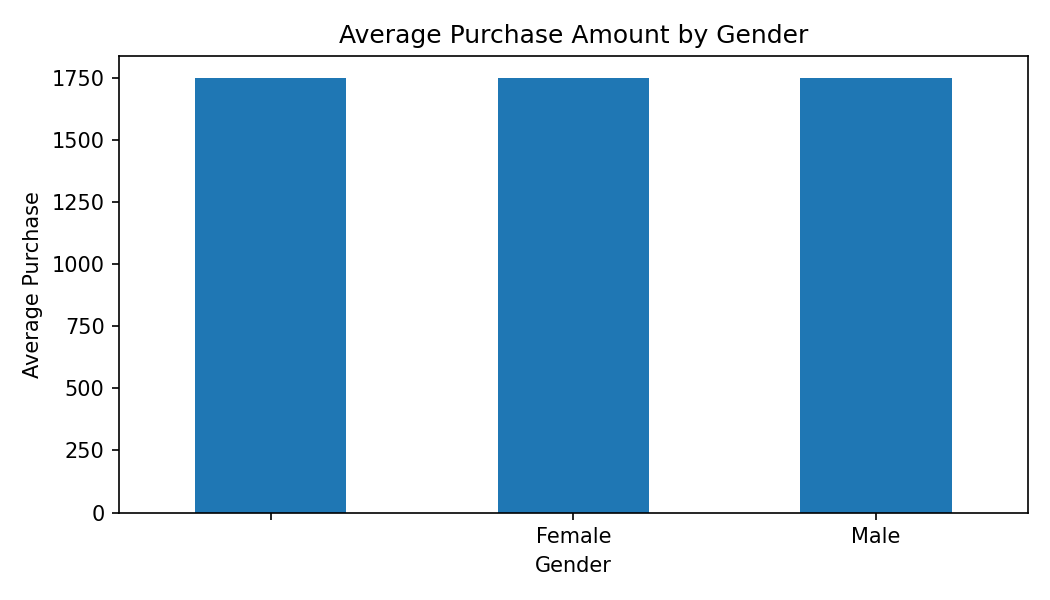

In [11]:
gender_purchase=df.groupby("gender")["purchase_amount"].mean().sort_values(ascending=False)
print(gender_purchase.round(2))
gender_purchase.plot(kind="bar",figsize=(7,4),title="Average Purchase Amount by Gender")
plt.tight_layout(); plt.show()

## 12. Annual Income vs Purchase Amount

Pearson correlation: nan\n

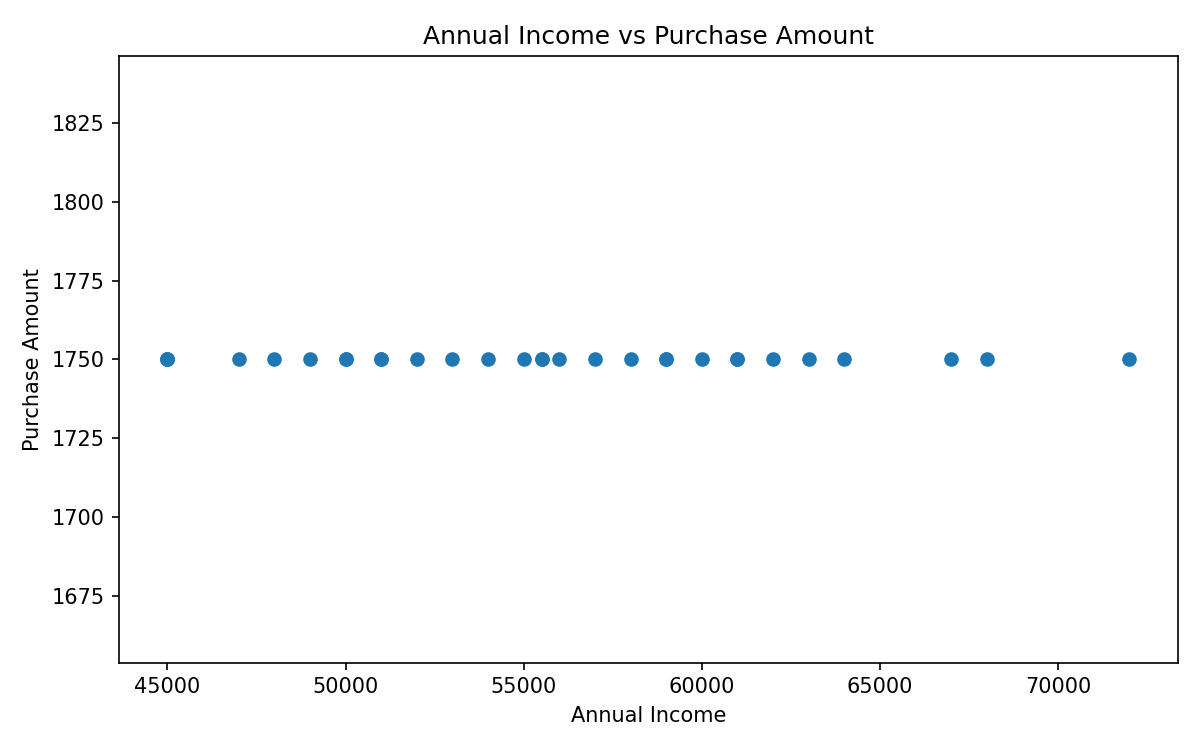

In [12]:
correlation=df[["annual_income","purchase_amount"]].corr().loc["annual_income","purchase_amount"]
print(f"Pearson correlation: {correlation:.3f}")
plt.figure(figsize=(8,5)); plt.scatter(df.annual_income,df.purchase_amount); plt.title("Annual Income vs Purchase Amount"); plt.xlabel("Annual Income"); plt.ylabel("Purchase Amount"); plt.tight_layout(); plt.show()

## 13. Monthly Purchase Trend

month
2026-01    38500.0
2026-02    14000.0

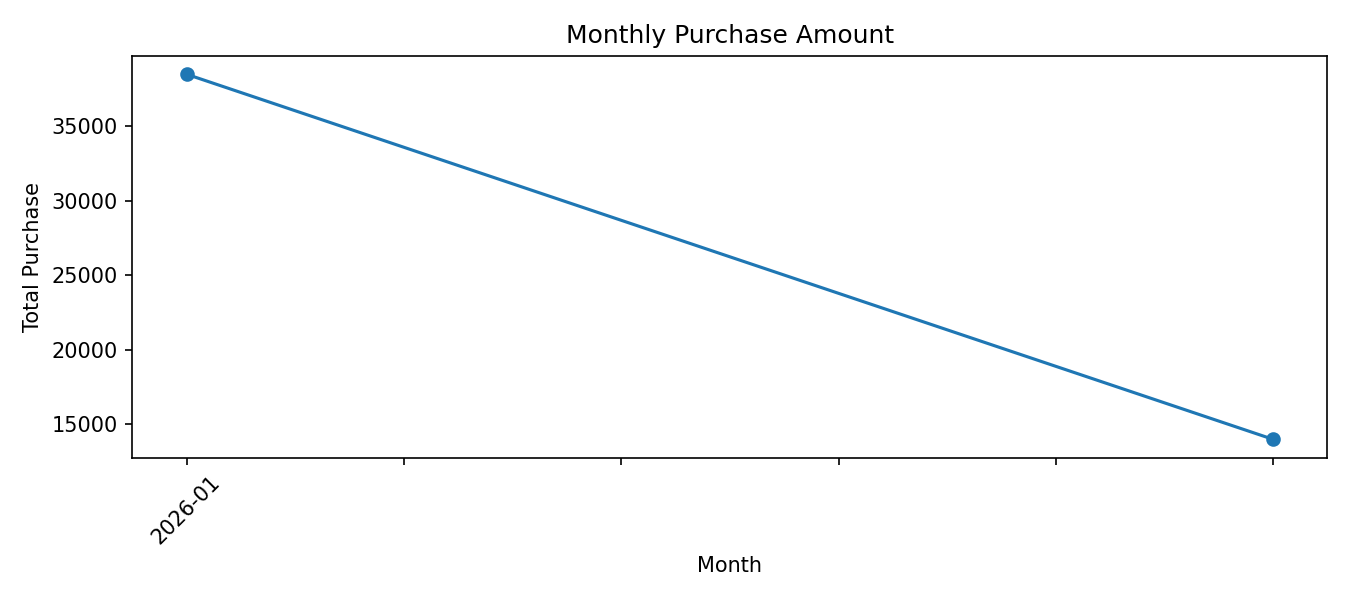

In [13]:
monthly_purchase=df.groupby("month")["purchase_amount"].sum()
print(monthly_purchase.round(2))
monthly_purchase.plot(kind="line",marker="o",figsize=(9,4),title="Monthly Purchase Amount"); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

## 14. Anomaly Detection

In [14]:
Q1=df["purchase_amount"].quantile(.25)
Q3=df["purchase_amount"].quantile(.75)
IQR=Q3-Q1
lower=Q1-1.5*IQR
upper=Q3+1.5*IQR
anomalies=df[(df.purchase_amount<lower)|(df.purchase_amount>upper)]
print("Q1:",round(Q1,2),"Q3:",round(Q3,2),"IQR:",round(IQR,2))
print("Lower bound:",round(lower,2),"Upper bound:",round(upper,2))
print("Anomalies:",len(anomalies))
anomalies[["customer_name","city","purchase_amount"]]

Q1: 1750.00\nQ3: 1750.00\nIQR: 0.00\nLower bound: 1750.00\nUpper bound: 1750.00\nAnomalies: 0\n

Empty DataFrame
Columns: [customer_name, city, purchase_amount]
Index: []

## 15. Key Insights

1. **Customer concentration:** Hyderabad has the largest customer count with **14 customers**.
2. **Gender distribution:** Male is the most represented category with **15 customers**.
3. **Income profile:** Average annual income is **55,766.67**, while median income is **55,500.00**.
4. **City-wise purchase behavior:** Hyderabad has the highest average purchase amount at **1,750.00**.
5. **Highest individual purchase:** Aarav Sharma has the highest recorded purchase amount at **1,750.00**.
6. **Income vs purchase relationship:** Pearson correlation is **nan**, indicating a weak relationship in this sample.
7. **Monthly trend:** 2026-01 has the highest total purchase amount at **38,500.00**.
8. **Anomaly check:** The IQR method identified **0** purchase-amount observation(s) outside the calculated bounds.

> These are observations from this sample dataset and should not be generalized beyond the sample without additional representative data.

## 16. Conclusion

The cleaned Task 1 dataset was analyzed using descriptive statistics, categorical and numerical distributions, city- and gender-level comparisons, correlation analysis, monthly trends, and IQR-based anomaly detection.

The notebook contains the executed results and visualizations required for SWYNEX Task 2.